(20640, 8)
Коэффициенты -36.50522691405021 -36.9324844291513 -37.04924224857544 -36.29685451366473 -36.94192418357396 -36.94570674983951 -37.363234584711684 -37.37643396185931
MedInc 0.4366932931343252
HouseAge 0.009435778033238536
AveRooms -0.10732204139090426
AveBedrms 0.6450656935198138
Population -3.9763894211976986e-06
AveOccup -0.003786542654970875
Latitude -0.42131437752714324
Longitude -0.4345137546747779
R2 0.606232685199805


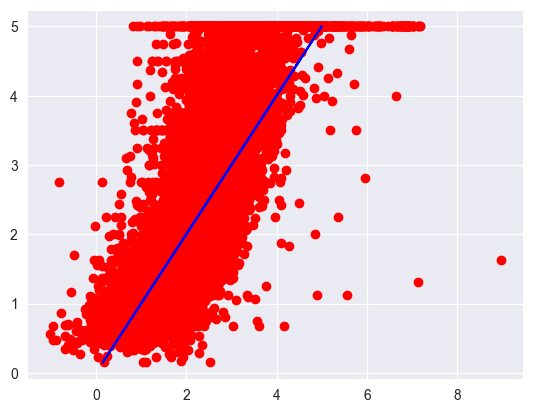

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

dataset = fetch_california_housing()
data = pd.DataFrame(dataset.data, columns=dataset.feature_names)
data['Price'] = dataset.target
X = data.drop('Price', axis=1)
Y = data['Price']

print(X.shape)

model = LinearRegression()
model.fit(X, Y)

print('Коэффициенты', *model.coef_ + model.intercept_)

_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

predicted = model.predict(X)

print('R2', model.score(X, Y))

plt.scatter(predicted, Y, c='r')
plt.plot(Y, Y, c='b')
plt.show()





R2 0.7286583856341055


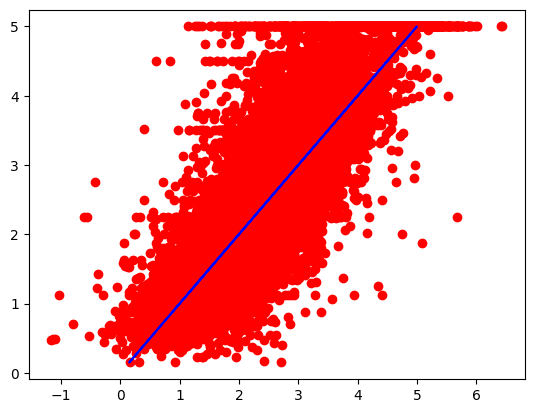

In [42]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, Y)
predicted_poly = model_poly.predict(X_poly)

print('R2', model_poly.score(X_poly, Y))

plt.scatter(predicted_poly, Y, c='r')
plt.plot(Y, Y, c='b')
plt.show()

Коэффициенты 1.2814835704847243 0.7702580418162461 0.5557200579178101 1.6924436387065844 0.749570668146084 0.7227159028041519
MedInc 0.5272597755200852
HouseAge 0.01603424685160705
AveRooms -0.19850373704682894
AveBedrms 0.9382198437419452
AveOccup -0.004653126818555172
Latitude -0.031507892160487265
R2 0.5424964991006291


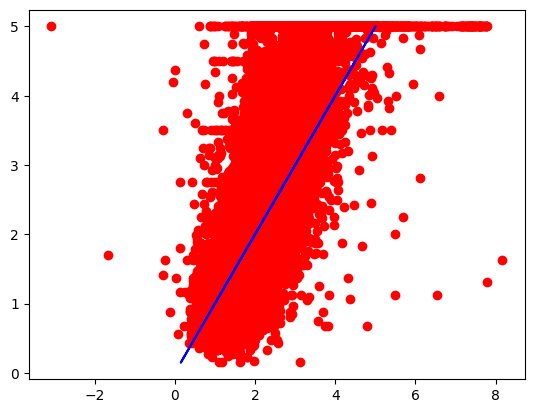

In [43]:
X = data.drop(['Price', 'Longitude', 'Population'], axis=1)
Y = data['Price']

model = LinearRegression()
model.fit(X, Y)

print('Коэффициенты', *model.coef_ + model.intercept_)

_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

predicted = model.predict(X)

print('R2', model.score(X, Y))

plt.scatter(predicted, Y, c='r')
plt.plot(Y, Y, c='b')
plt.show()

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())]) R2 0.5424964991006291


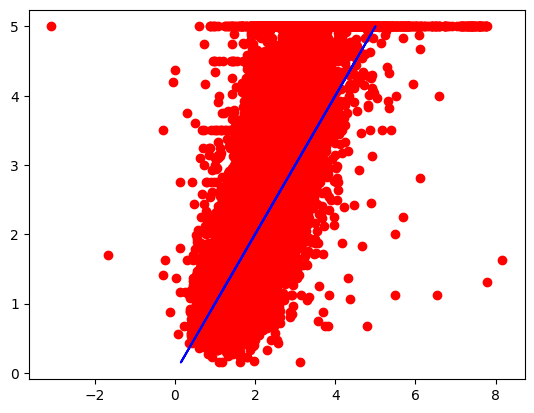

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR(kernel='linear'))]) R2 0.15292404595277276


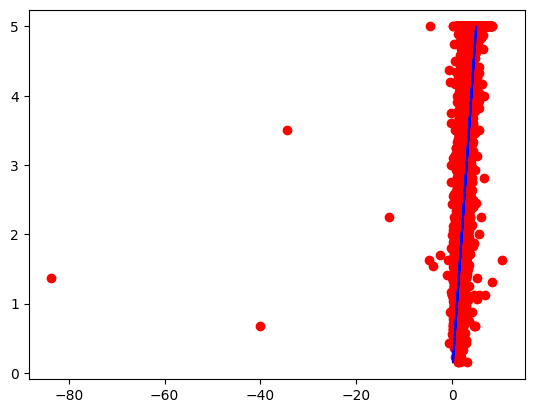

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR(C=10))]) R2 0.7085776280551037


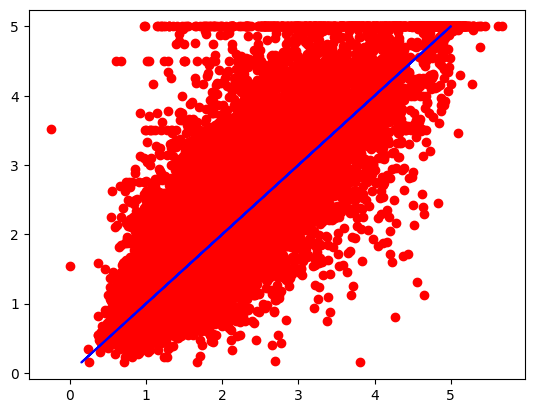

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR(kernel='poly'))]) R2 0.38129412310215927


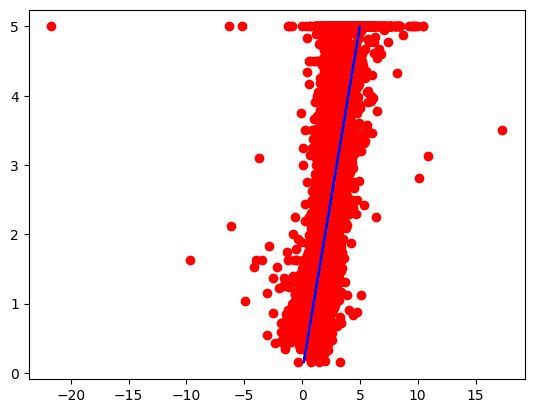

Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsRegressor())]) R2 0.7649314921147294


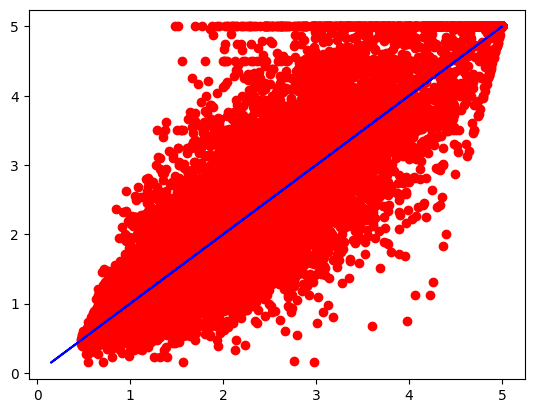

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', MLPRegressor(max_iter=3000))]) R2 0.7259738403997822


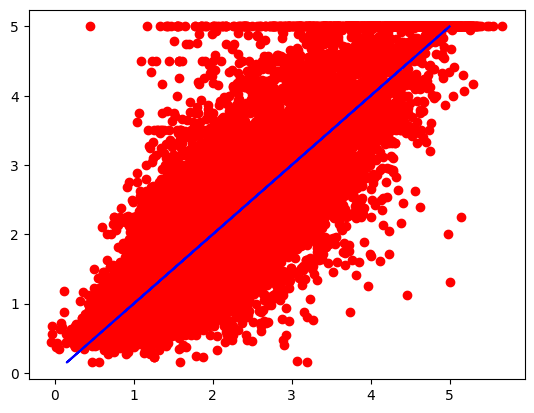

DecisionTreeRegressor(max_depth=5) R2 0.6307260306780871


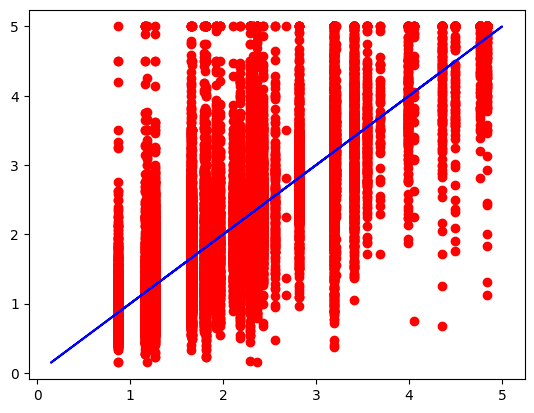

In [44]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def different_models(X, Y):
    models = {
        'LinearRegression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
        'SVR_lin': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='linear'))]),
        'SVR_rbf': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=10))]),
        'SVR_pol': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='poly', degree=3))]),
        'KNN': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=5))]),
        'MLP': Pipeline([('scaler', StandardScaler()), ('model', MLPRegressor(max_iter=3000))]),
        'DecisionTree': DecisionTreeRegressor(max_depth=5)
    }

    for name, model in models.items():
        model.fit(X, Y)
        predicted = model.predict(X)
        print(f'{model} R2', model.score(X, Y))
        plt.scatter(predicted, Y, c='r')
        plt.plot(Y, Y, c='b')
        plt.show()
different_models(X, Y)

In [1]:
from sklearn.datasets import load_diabetes

dataset = load_diabetes()

data = pd.DataFrame(dataset.data, columns=dataset.feature_names)
data['target'] = dataset.target
X = data.drop('target', axis=1)
Y = data['target']

different_models(X, Y)


AttributeError: info